In [1]:
import os
import time
import glob
import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord
import yaml

import importlib
import numpy as np
import pandas as pd
from math import floor

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

In [2]:
import sys
sys.path.append('observing-program/py')
sys.path.append('grism_sim/py')
os.environ['github_dir']='.'
import grism_dispersion
import footprintutils as fp
import roman_coords_transform as ctrans
from chi2_func import *
from overlap_cal_func import *
import optical_model

code_data_dir = 'observing-program/data/'
rctrans = ctrans.RomanCoordsTransform(file_path=code_data_dir)

In [3]:
optmod = optical_model.RomanOpticalModel()

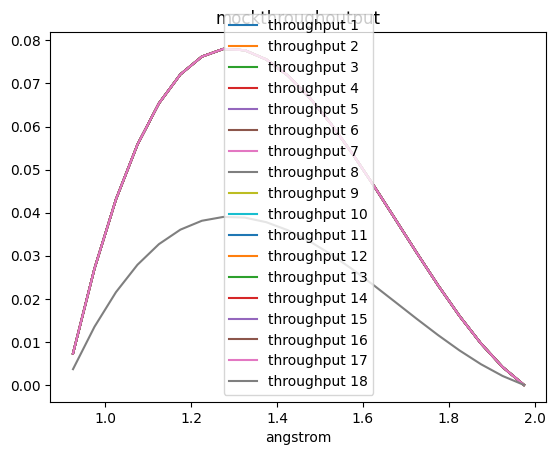

[0.925 0.975 1.025 1.075 1.125 1.175 1.225 1.275 1.325 1.375 1.425 1.475
 1.525 1.575 1.625 1.675 1.725 1.775 1.825 1.875 1.925 1.975]


In [4]:
_coeff = optmod._get_beam_trace(2044,2044,1, width=1, order="+1")

_1, _2, _3, _4, master_bins = bin_cut(_coeff) #left edges of bins

def throughput(x):
    coeff = [0.4, -0.9, -2.7, 3.3]
    scale = 1
    terms = [coeff[i]*x**(3-i) for i in range(4)]
    return scale*sum(terms)

def rescale(x):
    return (x - np.min(x)) / np.sum((x - np.min(x)))

lam = np.linspace(-2.5,2,22)
rescaled = rescale(throughput(lam))
master_bin_centers = (master_bins[1] - master_bins[0])/2 + master_bins
throughput_data = np.zeros((18, len(master_bin_centers)))
for i in range(18):

    sca_throughput = rescale(throughput(lam))
    throughput_data[i] = sca_throughput
    
throughput_data[17] *= 0.5
# plt.plot(master_bin_centers, throughput_data[5]/throughput_data[2], label = "throughput")
for i in range(18):
    plt.plot(master_bin_centers, throughput_data[i], label = f"throughput {i+1}")
plt.legend()
plt.title("mockthroughoutput")
plt.xlabel("angstrom")
plt.show()
print(master_bin_centers)

In [5]:
ra0 = 0
dec0 = 0
dithstep = 0.125*.2,0.125*.4
ndith = 2
decpa = 0.087
rapa = 0.0
decoffl = [decpa,decpa,-decpa,-decpa]
raoffl = [rapa,rapa/3,-rapa/3,-rapa]
pa_off = 0
pal = [-2.5+pa_off,2.5+pa_off,177.5+pa_off,182.5+pa_off]
pa = pal[0]
decoff = decoffl[0]#decpa/2
raoff = raoffl[0]

pointing_coords = []

survey = 3

if survey == 0:
    pointing_coords.append([ra0+raoff, dec0+decoff, pa])
elif survey == 1:
    for dith in range(0,ndith):
        decoff = decoffl[0]#decpa/2
        raoff = raoffl[0]
        pointing_coords.append([ra0+raoff+dith*dithstep[0], dec0+decoff+dith*dithstep[1], pa])
elif survey == 2:
    for pa,decoff,raoff in zip(pal,decoffl,raoffl):
        pointing_coords.append([ra0+raoff, dec0+decoff, pa])
elif survey == 3:
    for pa,decoff,raoff in zip(pal,decoffl,raoffl):
        for dith in range(0,ndith):
            #decoff = decpa/2
            #if pa > 100:
            #    decoff = -decpa/2
            pointing_coords.append([ra0+raoff+dith*dithstep[0], dec0+decoff+dith*dithstep[1], pa])

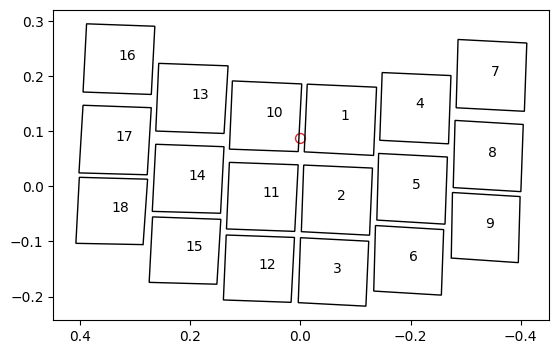

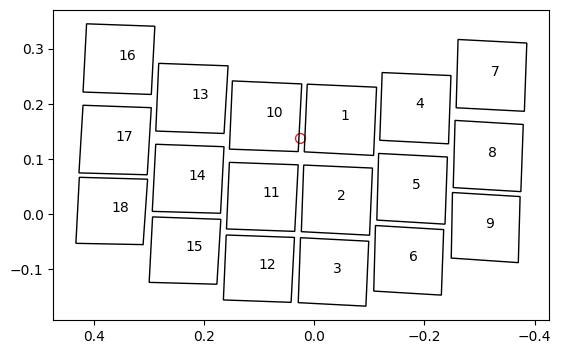

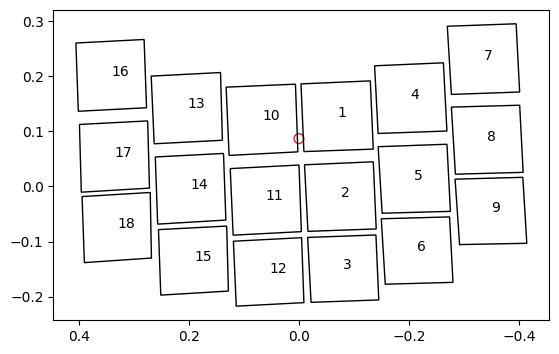

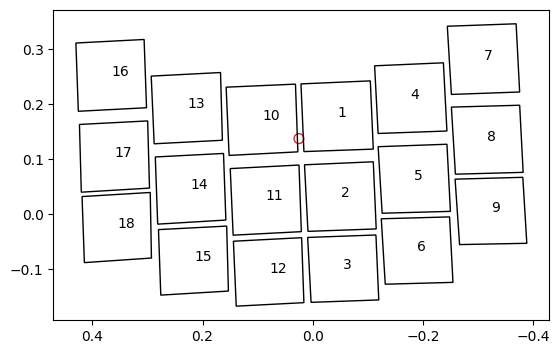

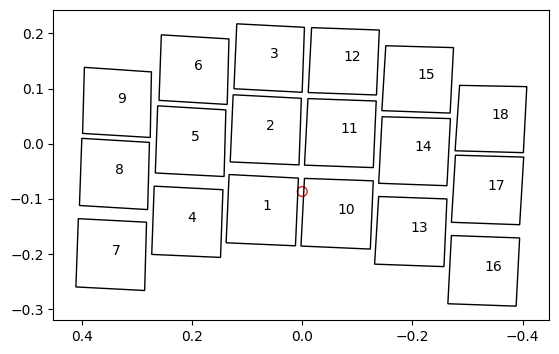

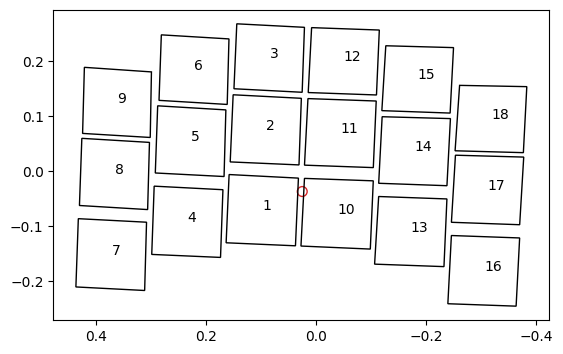

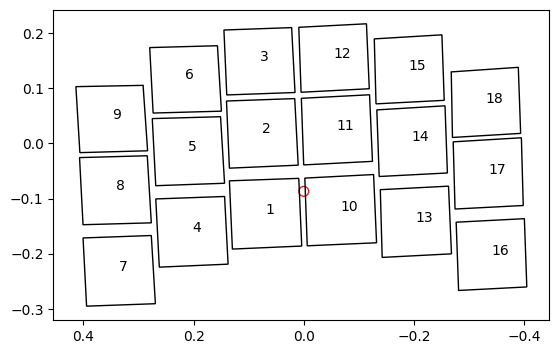

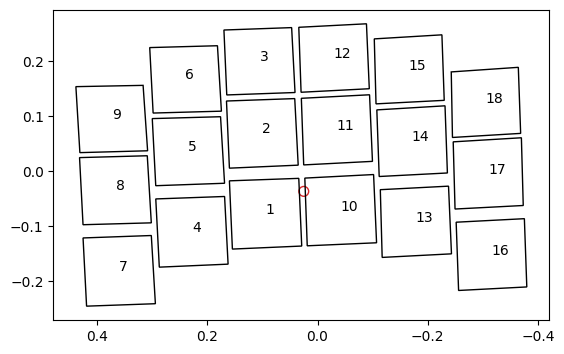

In [6]:
footprints = {}

for i in range(len(pointing_coords)):
  dfoot = rctrans.wfi_sky_pointing(pointing_coords[i][0], pointing_coords[i][1], pointing_coords[i][2], ds9=False, ax=None)
  for detector in range(1,19):
    footprints[detector+i*18] = dfoot[0][detector]

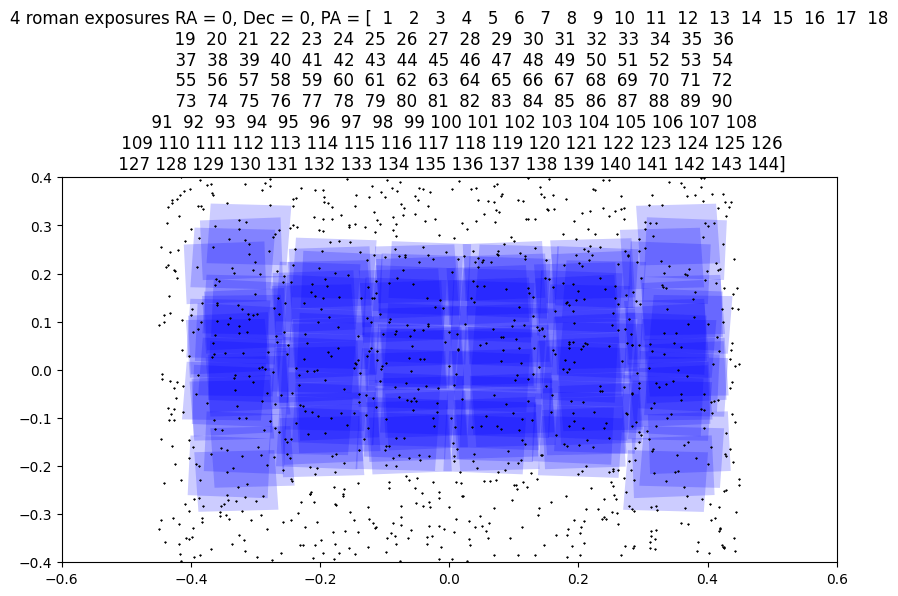

In [7]:
fig, ax = plt.subplots(figsize = (10,5))

##sim parameters
ns = 1000 # initial number of stars
exp = np.arange(len(footprints))+1
Nexp = len(exp)

for footprint in exp:
  data = footprints[footprint]
  corners = data['vertices']
  polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
  
  ax.add_patch(polygon)

plt.title("4 roman exposures RA = 0, Dec = 0, PA = {}".format(exp))

stars_x = (np.random.rand(ns) - 0.5)*0.9
stars_y = (np.random.rand(ns) - 0.5)*0.8

# stars_x = np.linspace(-0.5,0.5, 100)
# stars_x = np.tile(stars_x, 100)
# stars_y = np.linspace(-0.25,0.35,100)
# stars_y = np.sort(np.repeat(stars_y, 100))

plt.xlim(-0.6, 0.6)
plt.ylim(-0.4, 0.4)

plt.plot(stars_x, stars_y, "*", color = "black", markersize = 1)
# plt.gca().invert_xaxis()
# plt.plot(star[0], star[1], "*", color = "black", markersize = 3)
plt.show()

In [8]:
#create lists of paths for exposures

stars = np.zeros((ns,2))
stars[:,0] = stars_x
stars[:,1] = stars_y

select_exposure = {}

for footprint in exp:
  corners = footprints[footprint]['vertices']
  verts = np.concatenate((corners, [corners[0]]))
  path = Path(verts)
  footprints[footprint]['path'] = path
  ondetector = path.contains_points(stars)
  select_exposure[footprint] = ondetector



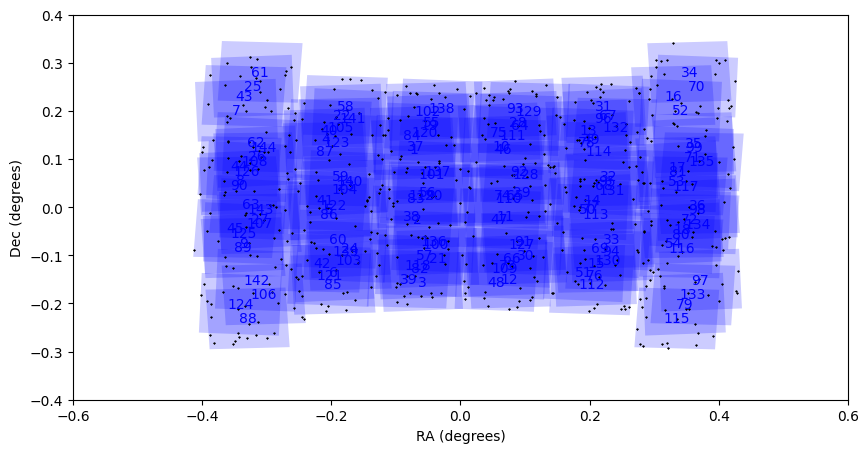

In [9]:
select_observed = np.array([False]*ns)
for footprint in exp:
  select_observed += select_exposure[footprint]
ns_obs = np.sum(select_observed)
stars_obs = stars[select_observed]

select_obs_exposure = {}
for footprint in exp:
  select_obs_exposure[footprint] = select_exposure[footprint][select_observed]

# Create a figure and an axes
fig, ax = plt.subplots(figsize = (10,5))
for footprint in exp:
  corners = footprints[footprint]['vertices']
  polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
  ax.add_patch(polygon)
  # Add the footprint label at the centroid of the polygon
  centroid = np.mean(corners, axis=0)
  ax.text(centroid[0], centroid[1], str(footprint), color='blue', fontsize=10, ha='center', va='center')

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
plt.xlim(-0.6, 0.6)
plt.ylim(-0.4, 0.4)
# Display the plot
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

In [10]:
#im gonna assume an arbitrary sigma k here
np.random.seed(17)
sigk = 0.1
sig_star = 0.5

true_k = np.random.normal(0,sigk**2,len(exp))

true_brightness = np.random.normal(1.0,sig_star**2,len(stars_obs))
sig_ij = 0.01
sig_lam = 0.1

true_k -= np.mean(true_k)
Nstars  = stars_obs.shape[0] #observed number of stars

exists_in_exp = np.zeros((Nexp, Nstars), dtype=bool)

for i in exp:
    mask = np.zeros(Nstars, dtype=bool) #initialise all false
        #loop through every detector (theres probably a faster way to do this)
        #do path contains points for each exposure
    path = footprints[i]['path']
    mask |= path.contains_points(stars_obs)      
    exists_in_exp[i-1] = mask


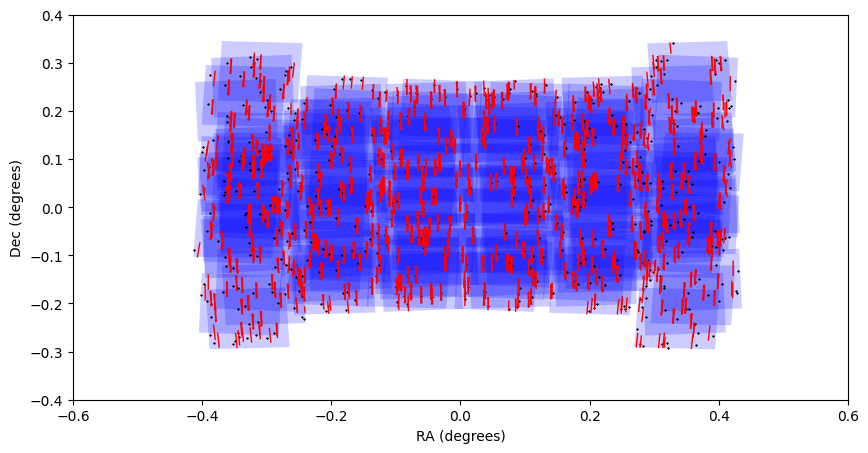

In [11]:
fig, ax = plt.subplots(figsize = (10,5))
for footprint in exp:
    corners = footprints[footprint]['vertices']
    polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
    ax.add_patch(polygon)
    # Add the footprint label at the centroid of the polygon
    centroid = np.mean(corners, axis=0)
    # ax.text(centroid[0], centroid[1], str(footprint), color='black', fontsize=10, ha='center', va='center')

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
plt.xlim(-0.6, 0.6)
plt.ylim(-0.4, 0.4)

# plt.xlim(-0.45, -0.30)
# plt.ylim(-0.08, 0.08)

"""apply grism information to stars"""

wvl_bins = len(master_bins)
stars_wvl = {key: val for key, val in zip(master_bins, [[] for _ in range(wvl_bins)])}

star_colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan']
starids = np.arange(len(stars_obs))

for i in range(len(exp)):
    star_mask = exists_in_exp[i]
    stars_in_exp = stars_obs[star_mask]
    stars_in_exp_ids = starids[star_mask]
    stars_in_exp_true_bright = true_brightness[star_mask]
    for star, id, bright in zip(stars_in_exp, stars_in_exp_ids, stars_in_exp_true_bright):
        fid = (i + 1)
        scaid = fid - 18 * np.floor((fid) / 18)  # Adjust fiducial ID to be in range 1-18
        if scaid == 0:
            scaid = 18
        det_coord = quad_to_square_transform(star[0], star[1], footprints[fid]['vertices'], src_size=4088)
        det_pixl = np.floor(det_coord)
        coeff = optmod._get_beam_trace(det_pixl[0], det_pixl[1], scaid, width=1, order="+1")
        x_binned, y_binned, colors, select_on_detector, bins = bin_cut(coeff)
        px, py = square_to_quad_transform(x_binned, y_binned, footprints[fid]['vertices'], src_size=4088)
        
        temp_dict = {key: val for key, val in [(bin, coord) for bin, coord in zip(bins, np.array([px,py]).T)]}
        plt.plot(px,py, color="red", lw = 1)
        for b,x,y in zip(bins, px, py):
            stars_wvl[b].append((fid, id, x, y))

for b in stars_wvl.keys():
    stars_wvl[b] = np.array(stars_wvl[b])

plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

In [12]:
start = time.time()
cali = run_calibration(stars_wvl, exp, stars_obs, sig_ij, sigk, true_brightness, true_k, throughput_data)
print(time.time() - start)

6.939205884933472


Text(0, 0.5, 'k')

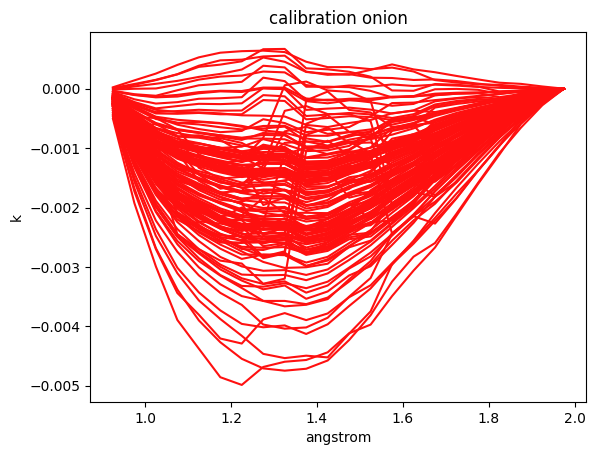

In [32]:
for _ in range(Nexp):
    if (_+1)%18 == 0:
        color = "#6a056a"
        # print(_+1)
        # plt.plot(master_bin_centers, cali[:,_]/2, color = color)
    else:
        color = "#ff1010"
        plt.plot(master_bin_centers, cali[:,_], color = color)
plt.title("calibration onion")
plt.xlabel("angstrom")
plt.ylabel("k")
# if (_+1)%18 == 0:
#     plt.show()



In [39]:
np.sum(cali[12])

np.float64(0.02766506817323642)

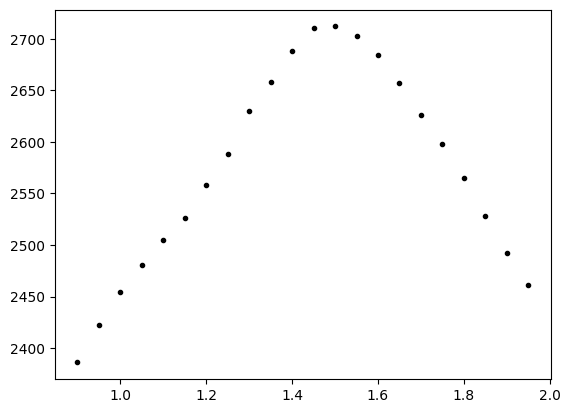

In [14]:
for b in stars_wvl.keys():
    plt.plot(b, len(stars_wvl[b]), "k.")

In [15]:
throughput_data[:,0].shape

(18,)

In [16]:
# m_ij = [true_brightness for _ in range(Nexp)]
# m_ij = np.array(m_ij)
# m_ij = np.where(exists_in_exp, true_brightness - true_k[:,None], 0.0)

# # m_lamij = rescaled[:, None, None] * m_ij[None, :, :]
# # mask = (m_lamij != 0)
# # error_array = np.random.normal(0,0.005,size = m_lamij.shape)
# # error_array *= mask
# # m_lamij += error_array


# # 0: wavelength
# # 1: exposure
# # 2: star

In [17]:
# # For each star j, collect the list of exposures containing it 
# # in_exp is a list of length Nstars, each element a list of exposures (differing lengths!)
# in_exp = [
#     [exp[i] for i in np.nonzero(exists_in_exp[:, j])[0]]
#     for j in range(Nstars)
# ]

# # Find unique overlap patterns using set, and discard those of length 1 (can't use stars that are only observed once)
# unique_patterns = {
#     tuple(lst) for lst in in_exp
#     if len(lst) > 1
# }
# overlaps = [list(pat) for pat in unique_patterns]


# # For each overlap pattern, build a boolean mask (length Nstars)
# # that is True exactly where in_detector[j] == that pattern.
# select_overlaps = []
# for pat in overlaps:
#     # build a boolean array of shape (Nexp,) marking which exposures are in this pattern
#     pat_mask = np.isin(exp, pat)
#     # compare full exists_in_exp against this mask column-wise, so for each star, if the pattern in exists_in_exp matches True, else False
#     star_mask = np.all(exists_in_exp == pat_mask[:, None], axis=0)
#     # so for e
#     # print(star_mask.shape)
#     select_overlaps.append(star_mask)

# # select_overlaps[l][j] is true if star j belongs to overlap l
# # shape (Nl, Nstars)


In [18]:
# Nl = len(overlaps)
# Nstarl = np.array([len(stars_obs[select_overlaps[l]]) for l in range(Nl)])

# m_il = np.zeros((len(exp), Nl))#this could probably be optimised like m_ij
# for i in range(len(exp)):
#   for l in range(Nl):
#     m_il[i,l] = np.mean(m_ij[i,:][select_overlaps[l]])

# m_il[i,l] is the mean brightness of stars in exposure i that are also in overlap l
# m_il is now a 2D array with shape (Nexp, Nl)

# generate m_lamil from m_lamij

# m_lamil = np.zeros((len(lam), len(exp), Nl))  # shape (Nlam, Nexp, Nl)
# for l in range(Nl):
#     for i in range(len(exp)):
#         m_lamil[:, i, l] = np.mean(m_lamij[:, i, :][:, select_overlaps[l]], axis=1)

# m_lamil is now a 3D array with shape (Nlam, Nexp, Nl)

In [19]:
# k_test = np.zeros(len(exp))

# start = time.time()
# resL_vec = minimize(chi2L_vec, k_test, method='L-BFGS-B', args=(m_il, sig_ij/np.sqrt(Nstarl), sigk), jac = True)
# print(time.time() - start)

# start = time.time()
# resJ_vec = minimize(chi2J_vec, k_test, method='L-BFGS-B', args=(m_ij, sig_ij, sigk), jac = True)
# print(time.time() - start)


In [20]:

# plt.plot((true_k/resJ_vec.x))
# plt.plot(true_k/resL_vec.x, "--")
# plt.ylim(-5,5)
plt.show();

In [21]:
# plt.hist(true_k/resJ_vec.x, bins = 30, alpha=0.5, label='J method')
# plt.show();

In [22]:
# fig, ax = plt.subplots(figsize = (5,5))
# xt = np.linspace(400,800,10)
# yt = -10*(xt-500)+3000

# tester = np.zeros((10,2))
# tester[:,0] = xt
# tester[:,1] = yt
# for det_pixl in tester:
#     fid = 8 + 1
#     coeff = optmod._get_beam_trace(det_pixl[0], det_pixl[1], fid, width=1, order="+1")
#     x_binned, y_binned, colors, select_on_detector, bins = bin_cut(coeff)
#     # print(bins)
#     px, py = square_to_quad_transform(x_binned, y_binned, footprints[fid]['vertices'], src_size=4088)
#     plt.plot(det_pixl[0], det_pixl[1], "ro", markersize = 3, label="trace center")
#     plt.plot(x_binned,y_binned, color="red", lw = 1)


# plt.plot(xt, yt, "k--", label="test line")
# plt.xlim(-500, 4588)
# plt.ylim(-500, 4588)
# plt.axvline(0, color='black', lw=0.5)
# plt.axhline(0, color='black', lw=0.5)   
# plt.axhline(4088, color='black', lw=0.5)
# plt.axvline(4088, color='black', lw=0.5)
# plt.show()